# Glacier-proximity relevance of absent DEM objects

**Numerical question.** Which absent Copernicus DEM cell–object incidences are geometrically separated from the registered glacier-proximity dependency region by a conservative nominal-footprint screen? This notebook reads the sealed geometry and inventory-join tables only. Separation does not establish raster validity, DEM substitutability, equivalent area, susceptibility, hazard, or climate attribution.

In [1]:
from pathlib import Path; import hashlib, json, matplotlib.pyplot as plt, numpy as np, pandas as pd
root = Path('..')
objects = pd.read_csv(root/'data/glacier_proximity_object_relevance/object_support.csv')
cells = pd.read_csv(root/'data/glacier_proximity_object_relevance/cell_support.csv')
groups = pd.read_csv(root/'data/glacier_proximity_object_relevance/group_support.csv')
summary = json.loads((root/'data/glacier_proximity_object_relevance/summary.json').read_text())
geometry_path = root/'data/glacier_proximity_object_relevance/geometry_manifest.json'; geometry = json.loads(geometry_path.read_text()); screen_path = root/'data/glacier_proximity_object_relevance/object_screen.csv'
assert hashlib.sha256(geometry_path.read_bytes()).hexdigest() == 'a03d0bd334f77b6d1fec53e00ce4dcfba37f79a87ead7bd9b1f07a349299b9d4' and hashlib.sha256(screen_path.read_bytes()).hexdigest() == geometry['files']['data/glacier_proximity_object_relevance/object_screen.csv']['sha256']
screen = pd.read_csv(screen_path); fields = ['cell_key','role','latitude','longitude','proximity_applicable','screen_relevant']; assert objects[fields].drop_duplicates().reset_index(drop=True).equals(screen[fields])
assert (len(objects), len(cells), len(groups)) == (32868, 3652, 68)
assert objects.groupby(['cell_key','instance']).size().eq(9).all() and cells.groupby('instance').size().eq(1826).all()
assert groups.groupby(['instance','dimension']).population_cells.sum().eq(1826).all()
assert objects.groupby('instance').size().eq(objects.groupby('instance').state.value_counts().unstack(fill_value=0).sum(axis=1)).all()
calculated = {i:{s:int(g.cell_state.eq(s).sum()) for s in ['no_absent_object_intersects_conservative_screen','unresolved','not_applicable']} for i,g in cells.groupby('instance')}
assert calculated == summary
stats = objects.groupby('instance').state.value_counts().unstack(fill_value=0); stats['population'] = objects.groupby('instance').size(); stats


state,absent_outside_conservative_screen,absent_relevance_unresolved,listed,population
instance,,,,
glo30,1065,8,15361,16434
glo90,1030,1,15403,16434


The join conserves all 16,434 candidate incidences per product. An absent-outside classification means only that the nominal object footprint is separated from the registered dependency region by the conservative screen; intersections remain unresolved.

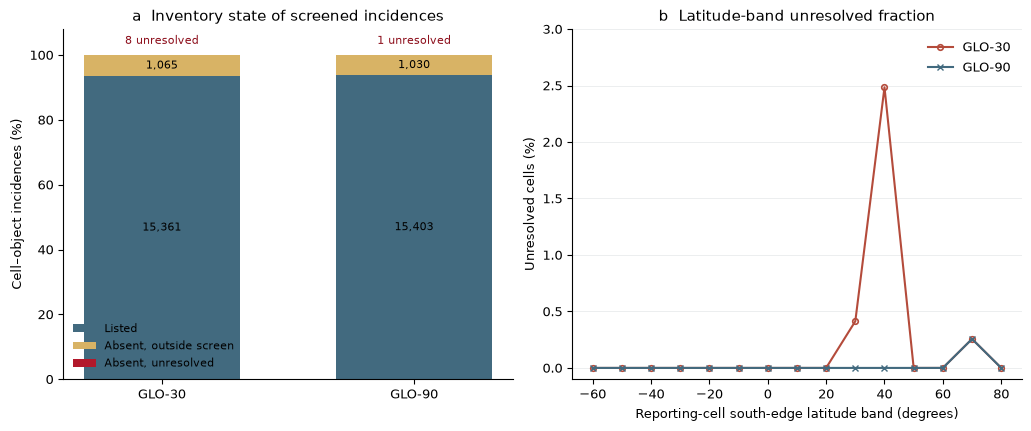

In [2]:
styles = {'glo30':{'color':'#b44b3b','marker':'o','markerfacecolor':'none','markeredgewidth':1.2}, 'glo90':{'color':'#426a7f','marker':'x'}}
states = [('listed','Listed','#426a7f'),('absent_outside_conservative_screen','Absent, outside screen','#d8b365'),('absent_relevance_unresolved','Absent, unresolved','#b2182b')]
plt.rcParams.update({'font.size':9, 'axes.spines.top':False, 'axes.spines.right':False})
fig, (ax, bx) = plt.subplots(1, 2, figsize=(10.2,4.2), constrained_layout=True)
x = np.arange(2); bottom = np.zeros(2)
for state, label, color in states:
    values = np.array([100*stats.loc[i,state]/stats.loc[i,'population'] for i in ['glo30','glo90']])
    bars = ax.bar(x, values, bottom=bottom, color=color, width=.62, label=label)
    for bar, value, count in zip(bars, values, [stats.loc[i,state] for i in ['glo30','glo90']]):
        if value > 1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_y()+value/2, f'{int(count):,}', ha='center', va='center', fontsize=8)
    bottom += values
for j, instance in enumerate(['glo30','glo90']):
    ax.annotate(f"{int(stats.loc[instance,'absent_relevance_unresolved'])} unresolved", (j,100), xytext=(0,8), textcoords='offset points', ha='center', fontsize=8, color='#8c0d1a')
ax.set(xticks=x, xticklabels=['GLO-30','GLO-90'], ylim=(0,108), ylabel='Cell–object incidences (%)', title='a  Inventory state of screened incidences')
ax.legend(frameon=False, loc='lower left', fontsize=8)
latitude = groups[groups.dimension.eq('latitude')].copy(); latitude['percent'] = 100*latitude.unresolved_cells/latitude.population_cells
for instance in ['glo30','glo90']:
    q = latitude[latitude.instance.eq(instance)].sort_values('group')
    bx.plot(q.group, q.percent, ms=4, lw=1.5, label=instance.upper().replace('GLO','GLO-'), **styles[instance])
bx.set(xlabel='Reporting-cell south-edge latitude band (degrees)', ylabel='Unresolved cells (%)', ylim=(-.1,3), title='b  Latitude-band unresolved fraction')
bx.grid(axis='y', color='#e4e7e9', linewidth=.5); bx.legend(frameon=False)
fig.savefig(root/'figures/glacier_proximity_object_relevance.png', dpi=300, bbox_inches='tight'); fig.savefig(root/'figures/glacier_proximity_object_relevance.pdf', bbox_inches='tight')
plt.show()


GLO-30 has eight unresolved absent-object incidences in six cells; GLO-90 has one incidence in one cell. The latitude grouping localizes those unresolved cells without changing the finite-population denominator or implying physical terrain support.